In [0]:
df = spark.table("workspace.default.titanic_dataset").toPandas()

In [0]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [0]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [0]:
df.isnull().mean().sort_values(ascending=False)

Cabin          0.771044
Age            0.198653
Embarked       0.002245
PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
dtype: float64

In [0]:
df.drop('Cabin', axis=1, inplace=True)

In [0]:
df.drop(columns=['Name', 'Ticket'], axis=1, inplace=True)
df.drop('PassengerId', axis=1, inplace=True)
num_cols = df.select_dtypes(exclude='object').columns
cat_cols = df.select_dtypes(include='object').columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
    
df.isnull().mean().sort_values(ascending=False)

/home/spark-da7b78ba-b945-426b-b607-08/.ipykernel/1997/command-5721433731877542-272690531:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/home/spark-da7b78ba-b945-426b-b607-08/.ipykernel/1997/command-5721433731877542-272690531:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are

Survived    0.0
Pclass      0.0
Sex         0.0
Age         0.0
SibSp       0.0
Parch       0.0
Fare        0.0
Embarked    0.0
dtype: float64

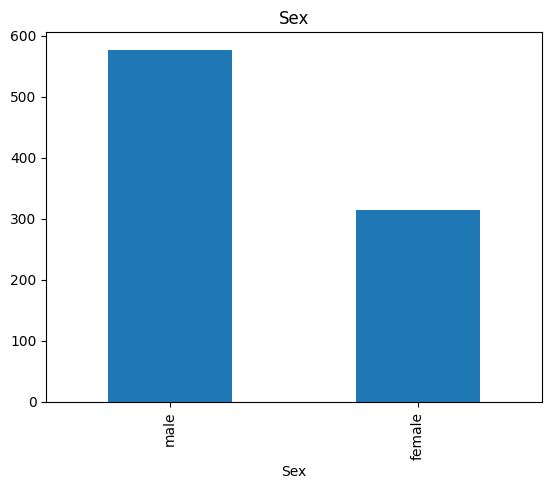

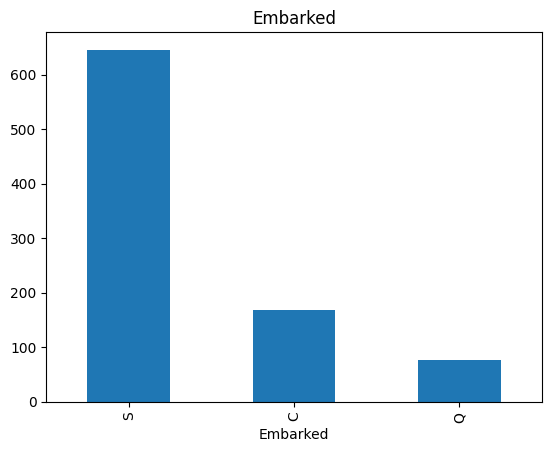

In [0]:

import matplotlib.pyplot as plt
for col in cat_cols:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()
# “There are more male passengers than female.”
# “Most passengers embarked from S port”


P class is catagorical
.Age, Fare, Parent, sibling is skewed. Survival is lightly skewed



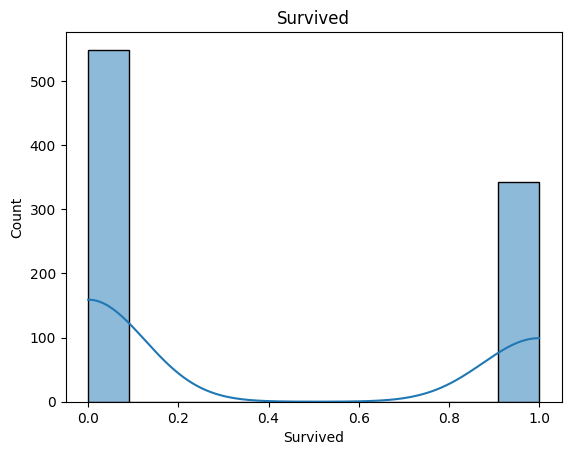

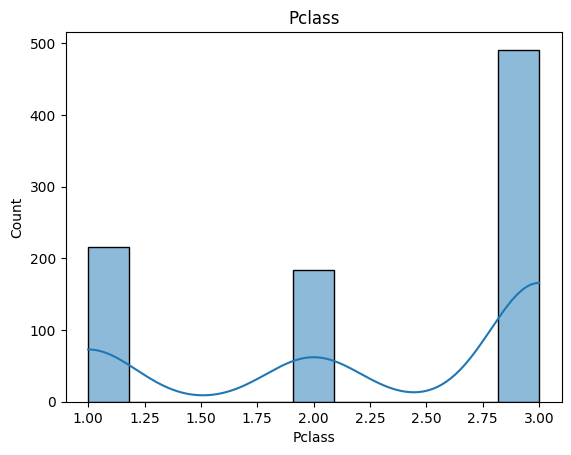

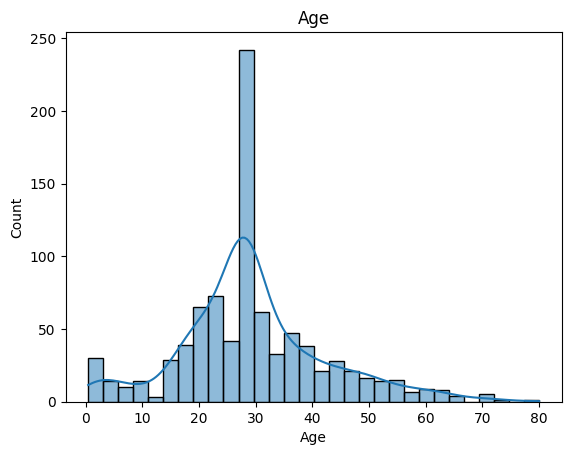

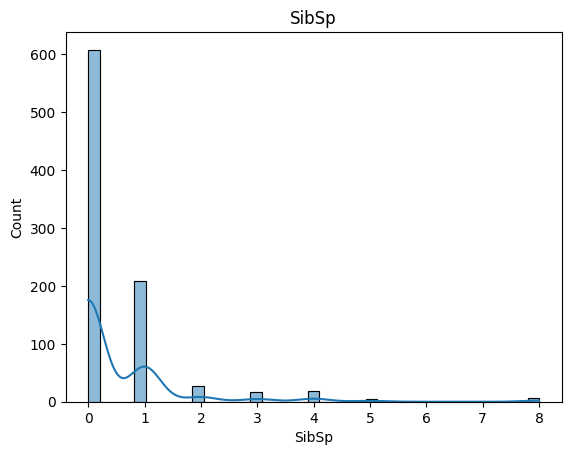

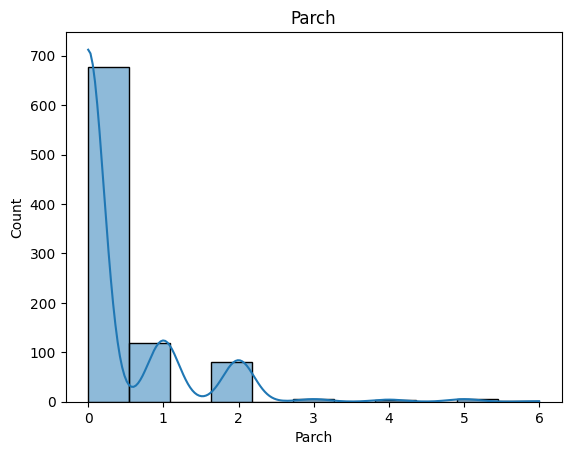

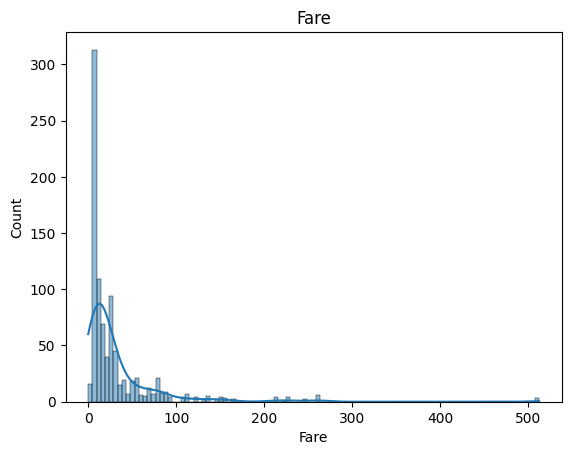

In [0]:
import seaborn as sns
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [0]:
# Since the distribution is skewed, I’ll apply IQR-based capping to handle potential outliers. Dont do that for target column
# “Even though Pclass is numeric, I’ll treat it as categorical and won’t apply outlier handling.”
# “I’m using IQR-based capping as it’s robust to skewed data and helps handle extreme values without removing observations.”
# “If the data were normally distributed, I could also consider Z-score, but here IQR is more appropriate.”
# “I evaluate each feature individually. If outliers are present, I apply IQR-based capping; otherwise, I leave the feature unchanged.”
# “I initially checked distributions using histograms/KDE and observed skewness. Ideally, I would validate outliers using boxplots per feature, but given time constraints, I applied IQR-based capping as a consistent approach.”“I initially checked distributions using histograms/KDE and observed skewness. Ideally, I would validate outliers using boxplots per feature, but given time constraints, I applied IQR-based capping as a consistent approach.”
import numpy as np
num_cols = df.select_dtypes(exclude='object').columns.drop(['Survived','Pclass'])
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = np.clip(df[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)
num_cols


Index(['Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

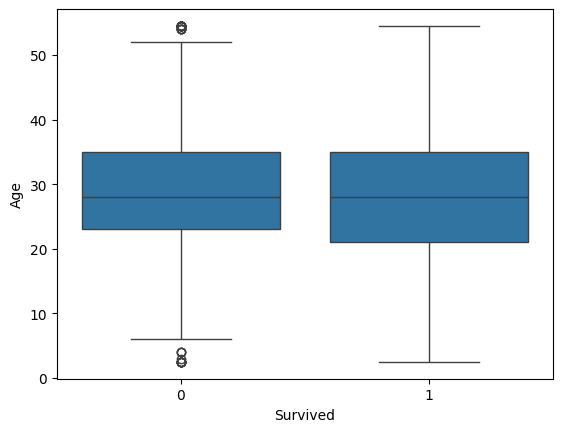

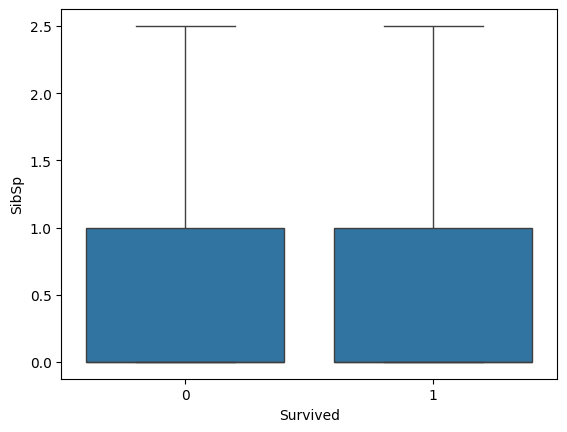

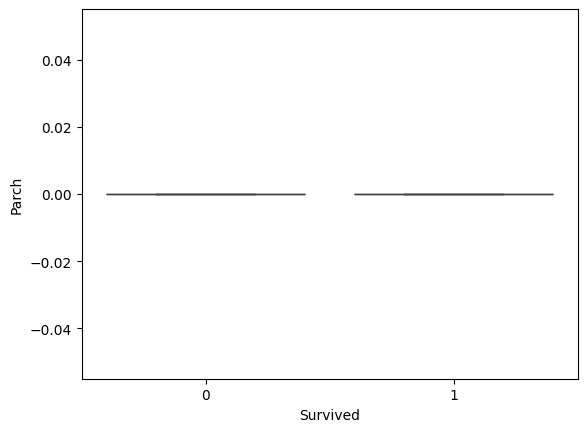

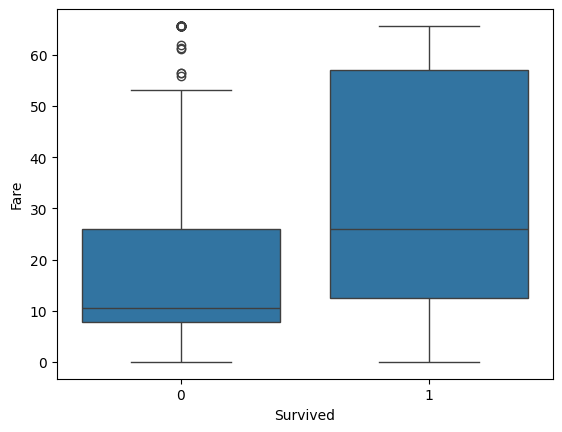

In [0]:
# BIVARIATE ANALYSIS
# Numerical vs Target
# “I’m analyzing how features influence the target.”
for col in num_cols:
    sns.boxplot(x=df['Survived'], y=df[col])
    plt.show()
# 🧠 STEP-BY-STEP THINKING (MEMORIZE THIS)
# 👉 Step 1: Compare medians

# Ask:
# 👉 “Is median higher for 0 or 1?”

# 👉 Step 2: Compare spread

# 👉 Is one group wider?

# 👉 Step 3: Look at overlap

# 👉 Are boxes very similar or different?

# “Age shows some variation across survival, but the difference is not very strong.”
# “SibSp does not show a strong relationship with survival.”
# “Parch has very low variance and may not be a strong predictor.”
# “Fare shows a strong relationship with survival, with higher fare passengers more likely to survive.”

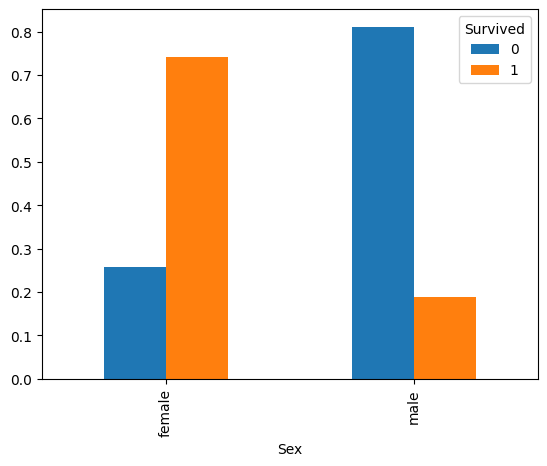

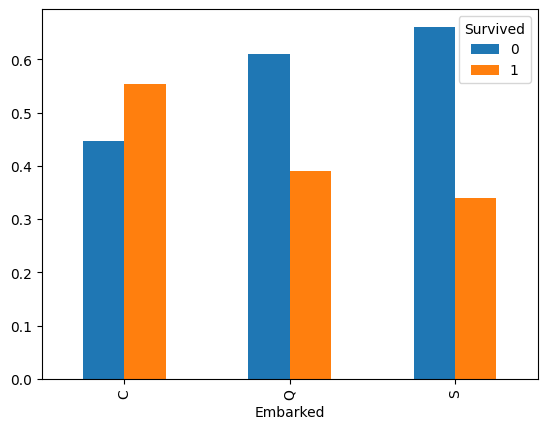

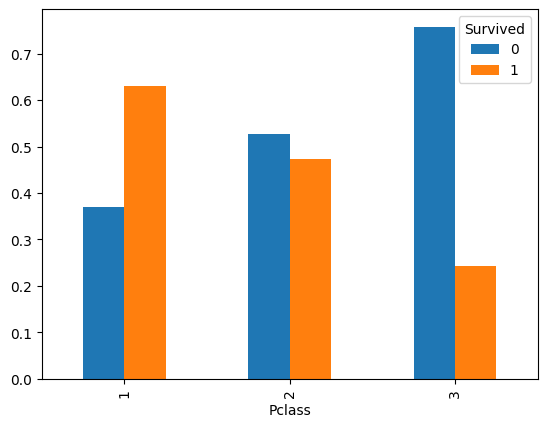

In [0]:
# Bivariate analysis
# Categorical vs Target

import pandas as pd
cat_cols = ['Sex', 'Embarked', 'Pclass']
for col in cat_cols[:3]:
    pd.crosstab(df[col], df['Survived'], normalize='index').plot(kind='bar')
    plt.show()
# Females are more likely to survive
# Passengers from port C have a higher survival rate and port S has lower survival rate, However, most passengers embarked from port S.
# Pclass 1 has higher survival rate and Pclass 3 has lower survival rate


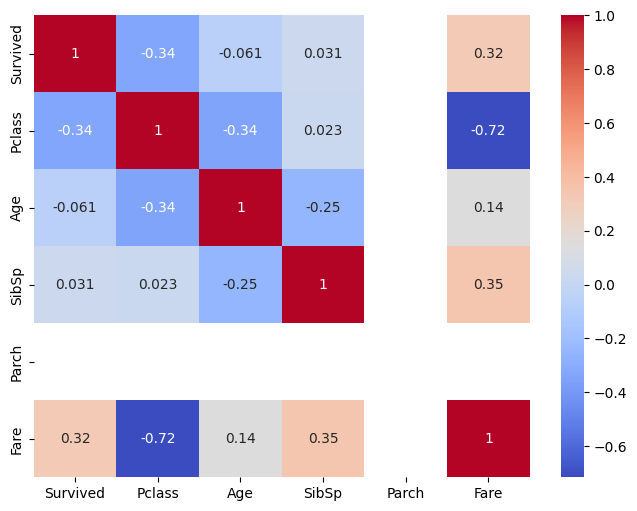

In [0]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df[df.select_dtypes(exclude='object').columns].corr(), annot=True, cmap='coolwarm')
plt.show()

In [0]:

# NUMERICAL ANALYSIS
# “This helps identify important numerical features.”
# Feature ↔ Feature (what you did)
# Use: check multicollinearity (are inputs redundant?)
df[num_cols].corr()

# if correlation > 0.8:

# Drop one
# OR
# Combine features
# “If features are highly correlated, it may lead to multicollinearity, so I would consider removing or combining them.”
# Here: “Numerical features show weak correlation among themselves, so multicollinearity is not a major concern.”


,Age,SibSp,Parch,Fare
Age,1.000000,-0.247806,NaN,0.144544
SibSp,-0.247806,1.000000,NaN,0.349615
Parch,NaN,NaN,NaN,NaN
Fare,0.144544,0.349615,NaN,1.000000


In [0]:
# NUMERICAL ANALYSIS
# “This helps identify important numerical features.”
# Feature ↔ Target - identify important predictors
df.head()
df.select_dtypes(include=['number']).corr()['Survived'].sort_values(ascending=False)
# “From numerical correlation, Fare and Pclass appear to be important predictors of survival, while Age, SibSp, and Parch show weak relationships.”

Survived    1.000000
Fare        0.317430
SibSp       0.031434
Age        -0.060622
Pclass     -0.338481
Parch            NaN
Name: Survived, dtype: float64

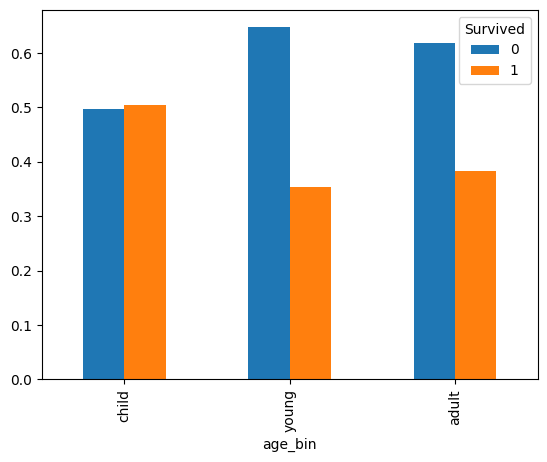

In [0]:
df['age_bin'] = pd.cut(df['Age'], bins=[0,18,35,60,100],
                      labels=['child','young','adult','senior'])
pd.crosstab(df['age_bin'], df['Survived'], normalize='index').plot(kind='bar')
plt.show()
# “Children tend to have higher survival rates compared to other age groups.”
# “Although Age had weak linear correlation, binning helped uncover a non-linear relationship.”

In [0]:
# ENCODING - “Converting categorical variables into numeric.”
df = pd.get_dummies(df, drop_first=True)
df.drop(columns='Age',axis=1,inplace=True)
df.head()



,Survived,Pclass,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,age_bin_young,age_bin_adult,age_bin_senior
0,0,3,1.0,0,7.2500,True,False,True,True,False,False
1,1,1,1.0,0,65.6344,False,False,False,False,True,False
2,1,3,0.0,0,7.9250,False,False,True,True,False,False
3,1,1,1.0,0,53.1000,False,False,True,True,False,False
4,0,3,0.0,0,8.0500,True,False,True,True,False,False


In [0]:
from sklearn.model_selection import train_test_split
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y)



In [0]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [0]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [0]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


0.8385650224215246
              precision    recall  f1-score   support

           0       0.92      0.83      0.87       150
           1       0.71      0.85      0.78        73

    accuracy                           0.84       223
   macro avg       0.82      0.84      0.82       223
weighted avg       0.85      0.84      0.84       223



In [0]:
df.shape

(891, 11)

In [0]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, y_prob)

np.float64(0.8953881278538812)

In [0]:
# Perfect — ab main tumhe **direct code-level fixes** deta hoon (no theory, only what to change) 🔥
# 👉 Goal: **your Titanic notebook → 8.5/10**

# ---

# # 🎯 🔧 1. Replace weak plots (IMPORTANT)

# ## ❌ Tumne kya kiya

# ```python
# df['Sex'].value_counts().plot(kind='bar')
# ```

# 👉 This is useless for modeling

# ---

# ## ✅ Replace with (impact-based plot)

# ```python
# sns.barplot(x='Sex', y='Survived', data=df)
# ```

# 👉 Same for:

# ```python
# sns.barplot(x='Pclass', y='Survived', data=df)
# sns.barplot(x='Embarked', y='Survived', data=df)
# ```

# ---

# # 🎯 🔧 2. Age analysis improve

# ## ❌ Tum:

# * sirf distribution dekh rahi thi

# ---

# ## ✅ Add this:

# ```python
# sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)
# ```

# 👉 OR better:

# ```python
# sns.boxplot(x='Survived', y='Age', data=df)
# ```

# ---

# # 🎯 🔧 3. Create Age bins (VERY IMPORTANT)

# ```python
# df['AgeBin'] = pd.cut(df['Age'], bins=[0,12,18,35,60,80],
#                       labels=['Child','Teen','Adult','MidAge','Senior'])
# ```

# 👉 Then:

# ```python
# sns.barplot(x='AgeBin', y='Survived', data=df)
# ```

# 🔥 This improves insight a lot

# ---

# # 🎯 🔧 4. Feature engineering (MUST ADD)

# ## ✅ Family size (VERY IMPORTANT)

# ```python
# df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
# ```

# ```python
# sns.barplot(x='FamilySize', y='Survived', data=df)
# ```

# ---

# ## ✅ IsAlone (VERY POWERFUL)

# ```python
# df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
# ```

# ```python
# sns.barplot(x='IsAlone', y='Survived', data=df)
# ```

# ---

# # 🎯 🔧 5. Missing value handling (fix)

# ## ❌ Weak approach:

# ```python
# df['Age'].fillna(df['Age'].mean(), inplace=True)
# ```

# ---

# ## ✅ Better:

# ```python
# df['Age'].fillna(df.groupby('Pclass')['Age'].transform('median'), inplace=True)
# ```

# 👉 More realistic

# ---

# # 🎯 🔧 6. Drop useless columns

# ```python
# df.drop(['Name','Ticket','Cabin'], axis=1, inplace=True)
# ```

# ---

# # 🎯 🔧 7. Encoding (clean)

# ```python
# df = pd.get_dummies(df, columns=['Sex','Embarked'], drop_first=True)
# ```

# ---

# # 🎯 🔧 8. Model (clear pipeline)

# ```python
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression

# X = df.drop('Survived', axis=1)
# y = df['Survived']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# model = LogisticRegression(max_iter=1000)
# model.fit(X_train, y_train)
# ```

# ---

# # 🎯 🔧 9. Evaluation (IMPORTANT ADD)

# ```python
# from sklearn.metrics import accuracy_score, classification_report

# y_pred = model.predict(X_test)

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print(classification_report(y_test, y_pred))
# ```

# ---

# # 🎯 🔥 10. Add THIS (very strong)

# ```python
# from sklearn.metrics import confusion_matrix
# sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
# ```

# ---

# # 🚀 FINAL RESULT AFTER THESE FIXES

# 👉 Your notebook becomes:

# ✔️ Insight-driven
# ✔️ Feature-engineered
# ✔️ Model-ready
# ✔️ Interview polished

# ---

# # 💬 FINAL IMPACT LINE (USE THIS)

# > “I focused on features that directly impact survival, such as gender, class, and family size, and engineered additional features to improve model performance.”

# ---

# # 🎯 MOST IMPORTANT CHANGE

# 👉 Stop:
# ❌ value_counts plots

# 👉 Start:
# ✔️ barplot with Survived

# ---

# # ❤️ Final feedback

# 👉 You already had:
# ✔️ structure

# 👉 After this:
# 🔥 You’ll have **impact + clarity**

# ---

# If you want, I can:

# * Turn this into **perfect Titanic notebook**
# * Or do **mock interview on this dataset**

# Just tell me 👍


In [0]:
# I reviewed your **Titanic notebook** carefully. Here’s a **clear, interviewer-style evaluation** — honest and actionable.

# ---

# # 🎯 📊 OVERALL VERDICT

# 👉 **Rating: 7.5 / 10 (Good, but slightly weaker than House Prices)**
# 👉 You can clear, but needs **polish in reasoning**

# ---

# # ✅ WHAT YOU DID WELL (STRONG AREAS)

# ---

# ## 🔥 1. Problem understanding (GOOD)

# ✔️ Correctly identified:

# * Classification problem
# * Target = Survived

# 👉 Good start

# ---

# ## 🔥 2. Basic EDA covered

# ✔️ Checked:

# * missing values
# * distributions
# * survival counts

# 👉 Structured approach 👍

# ---

# ## 🔥 3. Key features explored

# ✔️ You looked at:

# * Sex
# * Pclass
# * Age

# 👉 These are actually **correct important features**

# ---

# ## 🔥 4. Some feature engineering attempt

# ✔️ Tried to handle missing values
# ✔️ Some transformations

# 👉 Shows initiative

# ---

# # ⚠️ WHERE YOU LOST POINTS (IMPORTANT)

# ---

# ## ❌ 1. Insights are weak (MAIN ISSUE)

# 👉 You wrote things like:

# > “more males than females”

# 👉 But interviewer wants:

# > “Females have higher survival rate”

# ---

# ### 🔥 FIX:

# 👉 Always connect to target:

# ✔️ “Females have significantly higher survival probability”

# ---

# ## ❌ 2. Too much univariate, less bivariate

# 👉 You focused more on:

# * distributions

# 👉 But missed:

# * relationship with survival

# ---

# ### 🔥 You should do:

# ```python
# sns.barplot(x='Sex', y='Survived', data=df)
# ```

# 👉 This directly shows impact

# ---

# ## ❌ 3. No strong feature selection logic

# 👉 You explored features
# 👉 But didn’t clearly say:

# > “These are important features”

# ---

# ## ❌ 4. No clear modeling story

# 👉 Model part exists
# 👉 But explanation missing

# ---

# ## ❌ 5. Missing strong patterns

# 👉 Titanic has very clear rules:

# * Female → survived more
# * 1st class → survived more

# 👉 You didn’t emphasize strongly

# ---

# # 🧠 WHAT YOU SHOULD HAVE DONE

# ---

# ## 🎯 Strong insights (use these)

# 👉 Sex:

# > “Females had significantly higher survival rate compared to males.”

# ---

# 👉 Pclass:

# > “Passengers in higher classes had better survival chances.”

# ---

# 👉 Age:

# > “Children had slightly higher survival probability.”

# ---

# 👉 Fare:

# > “Higher fare passengers had better survival likelihood.”

# ---

# # 💬 PERFECT FINAL INSIGHT

# > “Survival was strongly influenced by gender, passenger class, and to some extent age and fare.”

# ---

# # 🚀 HOW TO IMPROVE (FAST)

# ---

# ## 🔹 1. Always connect feature → target

# 👉 Rule:

# > “Feature matters only if it affects target”

# ---

# ## 🔹 2. Use correct plots

# | Task         | Plot     |
# | ------------ | -------- |
# | Distribution | histplot |
# | Relationship | barplot  |

# ---

# ## 🔹 3. Speak impact, not counts

# ❌ “More males”
# ✔️ “Males had lower survival rate”

# ---

# # 🎯 FINAL COMPARISON

# | Area            | House Price     | Titanic     |
# | --------------- | --------------- | ----------- |
# | EDA             | ✅ Strong        | ⚠️ Moderate |
# | Insight quality | ⚠️ Needs polish | ❌ Weak      |
# | Modeling        | ✅ Good          | ⚠️ Okay     |
# | Overall         | 8/10            | 7.5/10      |

# ---

# # ❤️ FINAL FEEDBACK

# 👉 You understand:
# ✔️ tools
# ✔️ flow

# 👉 You need to improve:
# 🔥 **insight articulation**

# ---

# # 💬 One-line takeaway

# > “Always connect feature to target”

# ---

# # 🚀 Final boost

# You are:

# > **“Technically strong, needs storytelling polish”**

# ---

# If you want, I can:

# * Rewrite your Titanic into **perfect interview answer**
# * Or do **mock where I interrupt and correct you live**

# Just tell me 👍
